In [1]:
#Imports
import torch
import random
import os
from numpy import genfromtxt
import numpy as np
import matplotlib.pyplot as plt
import csv
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import diffrax
import equinox as eqx
import jax
import jax.nn as jnn
import jax.random as jr
import optax
from tqdm import tqdm

path = os.getcwd() + "/ambr"
files = os.listdir(path)
files_xls = [f for f in files if (f[-3:] == 'csv') and f[8] == '1']
df = pd.DataFrame()
files_xls

df = [None] * len(files_xls)

for f in range(len(files_xls)):
    data = pd.read_csv(path + "/" + files_xls[f])

    data.columns = data.columns.str.strip()
    data.columns = data.columns.str.replace('\ufeff', '', regex=False)

    if "Time" not in data.columns:
        print(files_xls[f], data.columns.tolist())
        raise ValueError(f"No Time column in {files_xls[f]}")

    # Extract run tag from filename
    run_name = files_xls[f].replace(".csv", "")

    df[f] = data
    df[f] = df[f].loc[:, ~df[f].columns.duplicated()]
    df[f] = df[f].sort_values("Time").reset_index(drop=True)
    df[f] = df[f].drop(columns=[c for c in df[f].columns
             if ('Optical density' not in c) 
             and ('pH' not in c) 
             and ('Time' not in c)])

Changing the column names (so it will be easier to manipulate them after)

In [2]:
run1_19_24 = ["Time" if x == "Time" else x + " run1" for x in df[0].columns]
run1_13_18 = ["Time" if x == "Time" else x + " run1" for x in df[1].columns]

# List of lists, one per dataframe
new_names = [run1_19_24, run1_13_18]

# Now assign
for d in range(len(df)):
    df[d].columns = new_names[d]

Merging the dataframes all together, according to the Time column

In [3]:
df_merged = df[0].copy()

for d in range(1, len(df)):
    df_merged = pd.merge(df_merged, df[d], on="Time", how="outer")

df_merged = df_merged.sort_values("Time").reset_index(drop=True)

Extracting the glucose data

In [4]:
path = os.getcwd() + "/Lorena_dataset/Glucose_files_310326/OfflineMetabolites_AMBR1.csv"
glucose1 = pd.read_csv(path, delimiter=';')
glc1 = glucose1[["Reactor","Time","Glucose"]]

Droping the Bioreactors we will not be including in the learning process

In [5]:
col_to_drop = ["Bioreactor 13 - Optical density run1", "Bioreactor 13 - pH run1",
               "Bioreactor 19 - Optical density run1", "Bioreactor 19 - pH run1"]

df_merged = df_merged.drop(columns=col_to_drop)

Keeping only the "Glucose", "Time" and "Bioreactor" columns

In [6]:
glucose_df = pd.DataFrame()
bior = None

for i in range(1, len(df_merged.columns), 2):
    col = df_merged.columns[i]
    bio_name = col[:-23]
    run_tag = col[-4:]

    if "run1" in col:
        bior = glc1[glc1["Reactor"] == bio_name][["Time", "Glucose"]].copy()
        bior = bior.rename(columns={"Glucose": f"{bio_name} {run_tag}"})

    # Rename Glucose column
    bior = bior.rename(columns={"Glucose": f"{bio_name} {run_tag}"})

    # Merge into glucose_df
    if glucose_df.empty:
        glucose_df = bior
    else:
        glucose_df = pd.merge(glucose_df, bior, on="Time", how="outer")

glucose_df = glucose_df.sort_values("Time").reset_index(drop=True)
glucose_df.columns

Index(['Time', 'Bioreactor 21 run1', 'Bioreactor 22 run1',
       'Bioreactor 23 run1', 'Bioreactor 24 run1', 'Bioreactor 14 run1',
       'Bioreactor 15 run1', 'Bioreactor 16 run1', 'Bioreactor 17 run1',
       'Bioreactor 18 run1'],
      dtype='object')

Creating the Biomass column

In [7]:
cols = list(df_merged.columns)
for i, col in enumerate(cols):
    if "Optical density" not in col:
        continue
    new_col_name = col.replace("Optical density", "Biomass")
    ph_col = col.replace("Optical density", "pH")
    ph_idx = df_merged.columns.get_loc(ph_col)
    df_merged.insert(ph_idx + 1, new_col_name, df_merged[col] * 0.4267)

Converting the data into array, as it is the format required for the neural ode library ()

In [19]:
#Lets start the loop to delete the NaNs !
ts_list = []
ys_list = []

for i in range(1,len(glucose_df.columns)):
    s = glucose_df[glucose_df.columns[i]].dropna()
    s1 = df_merged[df_merged.columns[1:][3*i-3:3*i][0]].dropna()
    s2 = df_merged[df_merged.columns[1:][3*i-3:3*i][1]].dropna()
    s3 = df_merged[df_merged.columns[1:][3*i-3:3*i][2]].dropna()

    ts_list.append(s.index.to_numpy(dtype=np.float32))
    ts_list.append(s1.index.to_numpy(dtype=np.float32))
    ts_list.append(s2.index.to_numpy(dtype=np.float32))
    ts_list.append(s3.index.to_numpy(dtype=np.float32))

    ys_list.append(s.to_numpy(dtype=np.float32))
    ys_list.append(s1.to_numpy(dtype=np.float32))
    ys_list.append(s2.to_numpy(dtype=np.float32))
    ys_list.append(s3.to_numpy(dtype=np.float32))

Randomly choosing a Bioreactor to Leav Out of the training in order to test it later

In [9]:
list_bior = [i[11:13] for i in glucose_df.columns[1:]]
test_bior = random.randint(0,len(list_bior)-1)
list_bior[test_bior]

'15'

In [10]:
start = 4 * test_bior 
stop = 4 * test_bior + 4

train = ys_list[:start-1] + ys_list[stop+1:]
test = ys_list[start:stop]

train_t = ts_list[:start-1] + ts_list[stop+1:]
test_t = ts_list[start:stop]

df_merged.columns

Index(['Time', 'Bioreactor 21 - Optical density run1',
       'Bioreactor 21 - pH run1', 'Bioreactor 21 - Biomass run1',
       'Bioreactor 22 - Optical density run1', 'Bioreactor 22 - pH run1',
       'Bioreactor 22 - Biomass run1', 'Bioreactor 23 - Optical density run1',
       'Bioreactor 23 - pH run1', 'Bioreactor 23 - Biomass run1',
       'Bioreactor 24 - Optical density run1', 'Bioreactor 24 - pH run1',
       'Bioreactor 24 - Biomass run1', 'Bioreactor 14 - Optical density run1',
       'Bioreactor 14 - pH run1', 'Bioreactor 14 - Biomass run1',
       'Bioreactor 15 - Optical density run1', 'Bioreactor 15 - pH run1',
       'Bioreactor 15 - Biomass run1', 'Bioreactor 16 - Optical density run1',
       'Bioreactor 16 - pH run1', 'Bioreactor 16 - Biomass run1',
       'Bioreactor 17 - Optical density run1', 'Bioreactor 17 - pH run1',
       'Bioreactor 17 - Biomass run1', 'Bioreactor 18 - Optical density run1',
       'Bioreactor 18 - pH run1', 'Bioreactor 18 - Biomass run1'],
  

In [15]:
class Func(eqx.Module):
    out_scale: jax.Array
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.out_scale = jnp.array(1.0)
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.softplus,
            final_activation=lambda x: x,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.out_scale * self.mlp(y)

class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Dopri5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6),
            adjoint=diffrax.DirectAdjoint(),
            max_steps=1000000,
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

lr = 1e-4
width_size = 32
depth = 3

def main(variable_data_list, variable_ts_list, n_epochs, seed=5678):

    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    data_size = 4

    model = NeuralODE(data_size, width_size, depth, key=model_key)
    optim = optax.adabelief(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi):
        y_pred = model(ti, yi[0])  # shape (T, data_size)
        sigma = 1.0
        loss_classic = jnp.mean(((yi - y_pred) / sigma) ** 2)
        negativity_loss = jnp.mean(jnp.maximum(0.0, -y_pred) ** 2)
        return loss_classic + 0.0 * negativity_loss

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state):
        loss, grads = grad_loss(model, ti, yi)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    loss_l = []
    n_vars = 4
    R2_scores = [[] for _ in range(n_vars)]

    # number of bioreactors = total entries / 4 variables each
    o = len(variable_data_list) // 4

    for epoch in tqdm(range(n_epochs)):
        idx = epoch % o

        # Get the 4 variables for this bioreactor
        glc_ys  = variable_data_list[4*idx]
        od_ys   = variable_data_list[4*idx + 1]
        ph_ys   = variable_data_list[4*idx + 2]
        bio_ys  = variable_data_list[4*idx + 3]

        # Get the corresponding time arrays
        glc_ts  = variable_ts_list[4*idx]
        od_ts   = variable_ts_list[4*idx + 1]
        ph_ts   = variable_ts_list[4*idx + 2]
        bio_ts  = variable_ts_list[4*idx + 3]

        # Use OD timestamps as the common time grid
        t = jnp.asarray(od_ts, dtype=jnp.float32)

        # Interpolate all variables onto the OD time grid
        ys = jnp.stack([
            jnp.interp(t, jnp.asarray(glc_ts), jnp.asarray(glc_ys)),  # glucose
            jnp.asarray(od_ys,  dtype=jnp.float32),                    # OD (reference)
            jnp.interp(t, jnp.asarray(ph_ts),  jnp.asarray(ph_ys)),   # pH
            jnp.interp(t, jnp.asarray(bio_ts), jnp.asarray(bio_ys)),  # biomass
        ], axis=1)  # shape (T, 4)

        y_true = torch.tensor(np.asarray(ys), dtype=torch.float32)

        loss, model, opt_state = make_step(t, ys, model, opt_state)

        y_pred = torch.tensor(np.asarray(model(t, ys[0])), dtype=torch.float32)

        loss_l.append(float(loss))

        for var_idx in range(n_vars):
            ss_res = torch.sum((y_true[:, var_idx] - y_pred[:, var_idx]) ** 2)
            ss_tot = torch.sum((y_true[:, var_idx] - torch.mean(y_true[:, var_idx])) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-12)
            R2_scores[var_idx].append(float(r2))

    return loss_l, R2_scores, t, ys, model

100 000 epochs = 30 min

In [16]:
# Run
n_epochs = 100000  # Max is 240000
loss, R, t, ys, model = main(train, train_t, n_epochs)

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [29:26<00:00, 56.62it/s]


Plotting the results (Loss, R2 score)

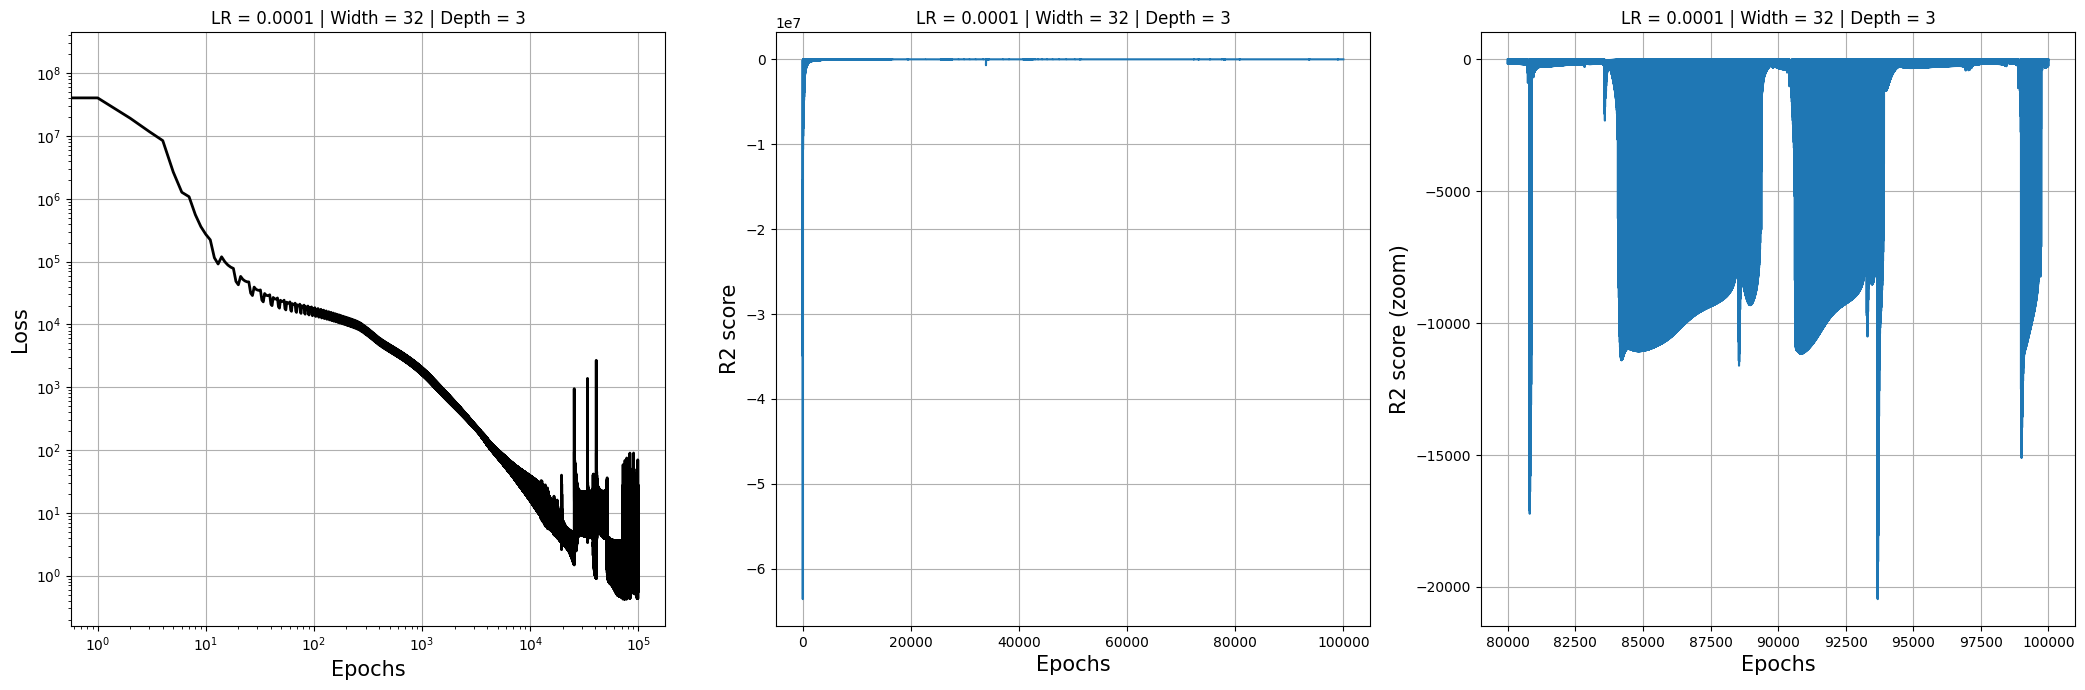

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(21, 7))

axs[0].plot(loss, color='black', linewidth=2)
axs[0].grid(True)
axs[0].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[0].set_xlabel('Epochs', fontsize=15)
axs[0].set_ylabel('Loss', fontsize=15)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

start_r = int(n_epochs * 0.8)  # zoom into the last 20% of training
t_r = np.arange(start_r, n_epochs, 1)

axs[1].plot(R[0])
axs[1].grid(True)
axs[1].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[1].set_xlabel('Epochs', fontsize=15)
axs[1].set_ylabel('R2 score', fontsize=15)

axs[2].plot(t_r, R[0][start_r:])
axs[2].grid(True)
axs[2].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[2].set_xlabel('Epochs', fontsize=15)
axs[2].set_ylabel('R2 score (zoom)', fontsize=15)

plt.tight_layout()
plt.show()

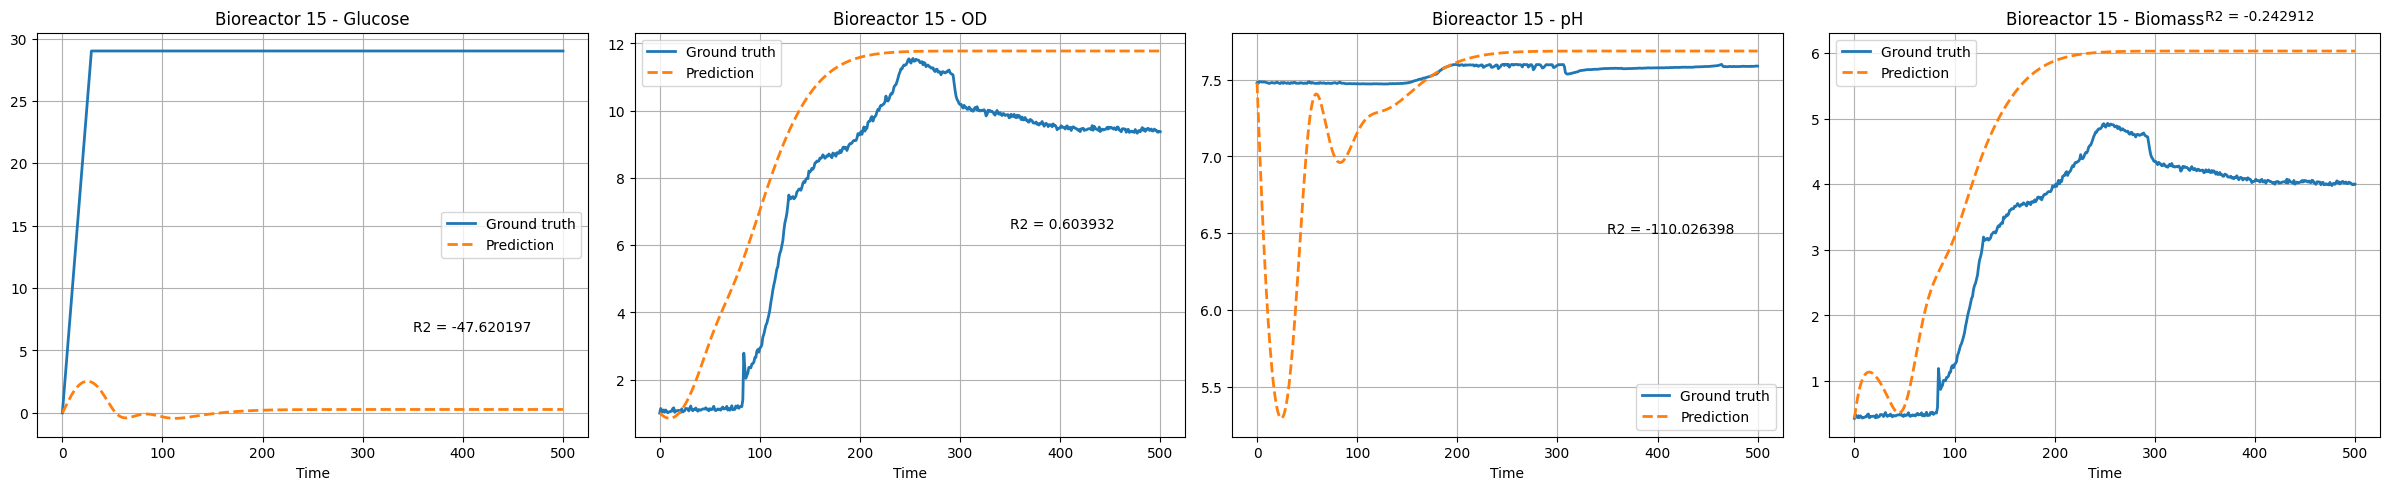

In [22]:
# --- Build the stacked ys and t for the test bioreactor ---
glc_ys  = test[0]
od_ys   = test[1]
ph_ys   = test[2]
bio_ys  = test[3]

glc_ts  = test_t[0]
od_ts   = test_t[1]
ph_ts   = test_t[2]
bio_ts  = test_t[3]

t_test = jnp.asarray(od_ts, dtype=jnp.float32)

ys_test = jnp.stack([
    jnp.interp(t_test, jnp.asarray(glc_ts), jnp.asarray(glc_ts)),
    jnp.asarray(od_ys,  dtype=jnp.float32),
    jnp.interp(t_test, jnp.asarray(ph_ts),  jnp.asarray(ph_ys)),
    jnp.interp(t_test, jnp.asarray(bio_ts), jnp.asarray(bio_ys)),
], axis=1)  # shape (T, 4)

# --- Run the model from the first time point ---
y_pred_test = model(t_test, ys_test[0])  # shape (T, 4)

# --- Compute R2 for each variable ---
y_true_test = torch.tensor(np.asarray(ys_test), dtype=torch.float32)
y_pred_test_torch = torch.tensor(np.asarray(y_pred_test), dtype=torch.float32)

var_names = ["Glucose", "OD", "pH", "Biomass"]
# --- Plot predictions vs ground truth ---
fig, axs = plt.subplots(1, 4, figsize=(24, 5))
for var_idx, name in enumerate(var_names):
    ss_res = torch.sum((y_true_test[:, var_idx] - y_pred_test_torch[:, var_idx]) ** 2)
    ss_tot = torch.sum((y_true_test[:, var_idx] - torch.mean(y_true_test[:, var_idx])) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-12)
    y_r2 = (y_pred_test[:, ][var_idx][1]+y_pred_test[:, ][var_idx][-1])/2
    axs[var_idx].plot(t_test, ys_test[:, var_idx], label="Ground truth", linewidth=2)
    axs[var_idx].plot(t_test, y_pred_test[:, var_idx], label="Prediction", linewidth=2, linestyle="--")
    axs[var_idx].set_title("Bioreactor " + list_bior[test_bior] + " - " + name)
    axs[var_idx].set_xlabel("Time")
    axs[var_idx].legend()
    axs[var_idx].text(t_test[-1]*0.7, 6.5, f"R2 = {r2:.6f}")
    axs[var_idx].grid(True)

plt.tight_layout()
plt.show()